In [1]:
import pandas as pd
import numpy as np
import keras
import tensorflow as tf
import shap
import matplotlib.pyplot as plt
import h5py

seed=42

# 1. Data processing

In [2]:
from google.colab import drive
drive.mount('/content/drive')
f = h5py.File('/content/drive/MyDrive/Table_TNG300_snapshot99_SubhalosProp_HaloProp.hdf5', 'r')
f.keys()

Mounted at /content/drive


<KeysViewHDF5 ['GroupPos_halo', 'M200_halo', 'Spin_halo', 'SubGroupSFR', 'SubGroupStellarPhotom_g', 'SubGroupStellarPhotom_i', 'SubGroupStellarPhotom_r', 'SubGroupStellarPhotom_z', 'SubhaloCM', 'SubhaloGrNr', 'SubhaloId', 'SubhaloMassType', 'SubhaloPos', 'b1', 'b2', 'c200_halo', 'd3_halo', 'd5_halo', 'd8_halo', 'd_minima', 'd_node', 'd_saddle_1', 'd_saddle_2', 'd_skel', 'zform_halo']>

In [3]:
GrNr = np.asarray(f['SubhaloGrNr'])
mass = np.asarray(f['SubhaloMassType'][:,4])
halo_mass = np.asarray(f['M200_halo'])
d3 = np.asarray(f['d3_halo'])
d5 = np.asarray(f['d5_halo'])
d8 = np.asarray(f['d8_halo'])
c_200= np.asarray(f['c200_halo'])
z = np.asarray(f['zform_halo'])
d_min = np.asarray(f['d_minima'])
d_node = np.asarray(f['d_node'])
d_saddle_1 = np.asarray(f['d_saddle_1'])
d_saddle_2 = np.asarray(f['d_saddle_2'])
d_skel = np.asarray(f['d_skel'])
b1 = np.asarray(f['b1'])
spin = np.asarray(f['Spin_halo'])

In [4]:
indices_cambio = np.unique(GrNr, return_index=True)[1]
mass_filtrada = mass[indices_cambio]
halo_mass_filtrada = halo_mass[indices_cambio]
d3 = d3[indices_cambio]
d5 = d5[indices_cambio]
d8 = d8[indices_cambio]
c_200= c_200[indices_cambio]
z = z[indices_cambio]
d_min = d_min[indices_cambio]
d_node = d_node[indices_cambio]
d_saddle_1 = d_saddle_1[indices_cambio]
d_saddle_2 = d_saddle_2[indices_cambio]
d_skel = d_skel[indices_cambio]
b1 = b1[indices_cambio]
spin = spin[indices_cambio]

indices_comunes=np.where((np.log10(mass_filtrada) >8.75)*(np.log10(halo_mass_filtrada) >10.5))[0]

mass_filtrada = np.log10(mass_filtrada[indices_comunes])
halo_mass_filtrada = np.log10(halo_mass_filtrada[indices_comunes])
d3 = d3[indices_comunes]
d5 = d5[indices_comunes]
d8 = d8[indices_comunes]
c_200= c_200[indices_comunes]
z = z[indices_comunes]
d_min = d_min[indices_comunes]
d_node = d_node[indices_comunes]
d_saddle_1 = d_saddle_1[indices_comunes]
d_saddle_2 = d_saddle_2[indices_comunes]
d_skel = d_skel[indices_comunes]
b1 = b1[indices_comunes]
spin = spin[indices_comunes]

/tmp/ipykernel_569/4160979324.py:17: RuntimeWarning: invalid value encountered in log10
  indices_comunes=np.where((np.log10(mass_filtrada) >8.75)*(np.log10(halo_mass_filtrada) >10.5))[0]


In [5]:
X = np.column_stack((halo_mass_filtrada,d3, d5, d8, c_200, z, spin, d_min, d_node, d_saddle_1,d_saddle_2, d_skel))
y = b1.reshape(-1, 1)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

scaler = StandardScaler()
y_norm = scaler.fit_transform(y)

X_norm.shape, y_norm.shape

((174607, 12), (174607, 1))

In [7]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_norm,y_norm,test_size=0.30,random_state=seed)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=seed)
X_train.shape, X_val.shape, X_test.shape

((97779, 12), (24445, 12), (52383, 12))

# 2. Model loading

In [8]:
### --- Download previously trained model
!gdown 'https://drive.google.com/file/d/1WT0bDVNxaHRCoFrz_DBXHOwtix6R4WKT/view?usp=sharing'

/usr/local/lib/python3.12/dist-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=1WT0bDVNxaHRCoFrz_DBXHOwtix6R4WKT
  warnings.warn(
Downloading...
From: https://drive.google.com/file/d/1WT0bDVNxaHRCoFrz_DBXHOwtix6R4WKT/view?usp=sharing
To: /content/view?usp=sharing
68.4kB [00:00, 42.4MB/s]


In [10]:
### --- load model

model = keras.saving.load_model('GalaxyBiasResNet.keras')
#model.summary() #uncomment this line to see network layers

# 3. SHAP Explanations

In [11]:
def predict_for_shap(x_2d):
    x_3d = tf.cast(np.asarray(x_2d).reshape((-1, X_train.shape[1], 1)), tf.float32)
    return model(x_3d, training=False).numpy().reshape(-1)

rng = np.random.default_rng(42)
background_idx = rng.choice(X_train.shape[0], size=500, replace=False)
explain_idx    = rng.choice(X_test.shape[0],  size=1800, replace=False)

X_background = X_train[background_idx]
X_explain    = X_test[explain_idx]

explainer   = shap.KernelExplainer(predict_for_shap, X_background)
shap_values = explainer.shap_values(X_explain, nsamples=120)

if isinstance(shap_values, list):
    shap_values = shap_values[0]

features = ['halo_mass', 'd3', 'd5', 'd8', 'c_200', 'z', 'spin',
            'd_min', 'd_node', 'd_saddle_1', 'd_saddle_2', 'd_skel']

  0%|          | 0/1800 [00:00<?, ?it/s]

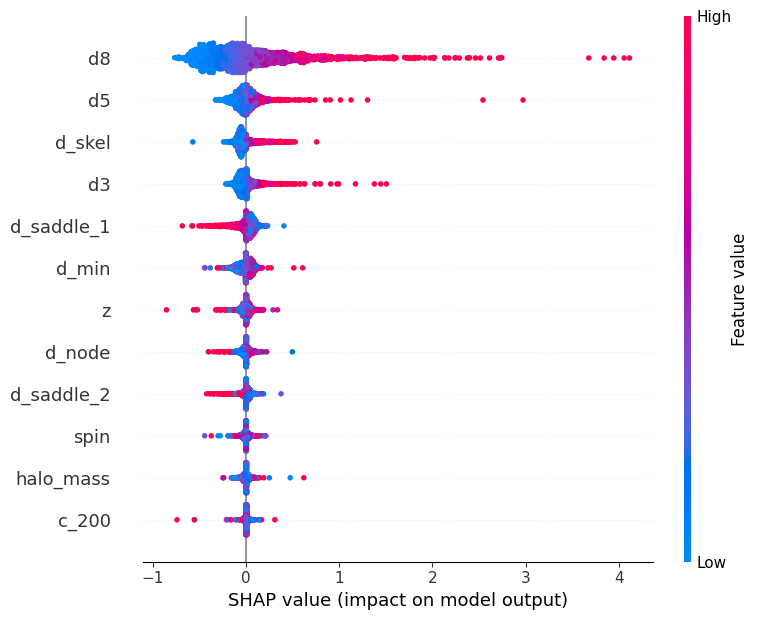

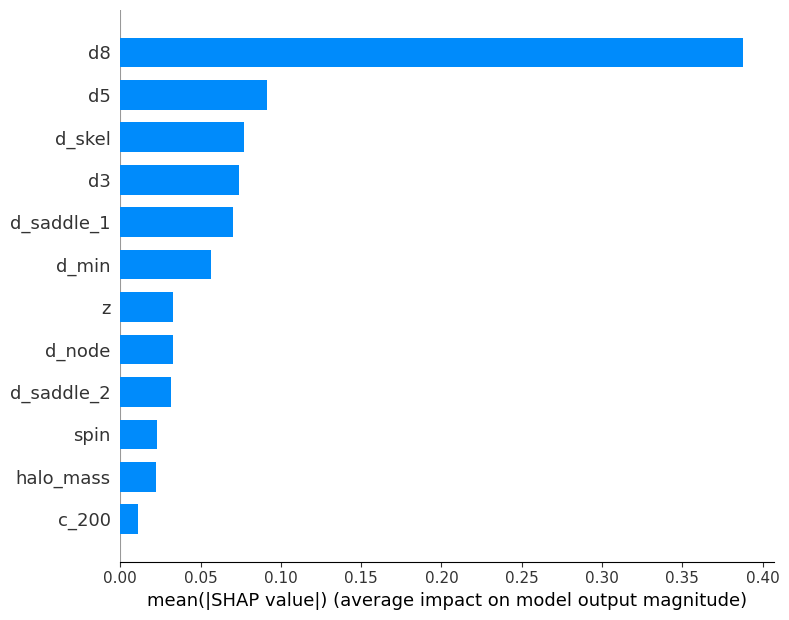

In [12]:
# Global feature importance — beeswarm
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_explain, feature_names=features, show=True)

# Global feature importance — bar chart
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_explain, feature_names=features, plot_type='bar', show=True)

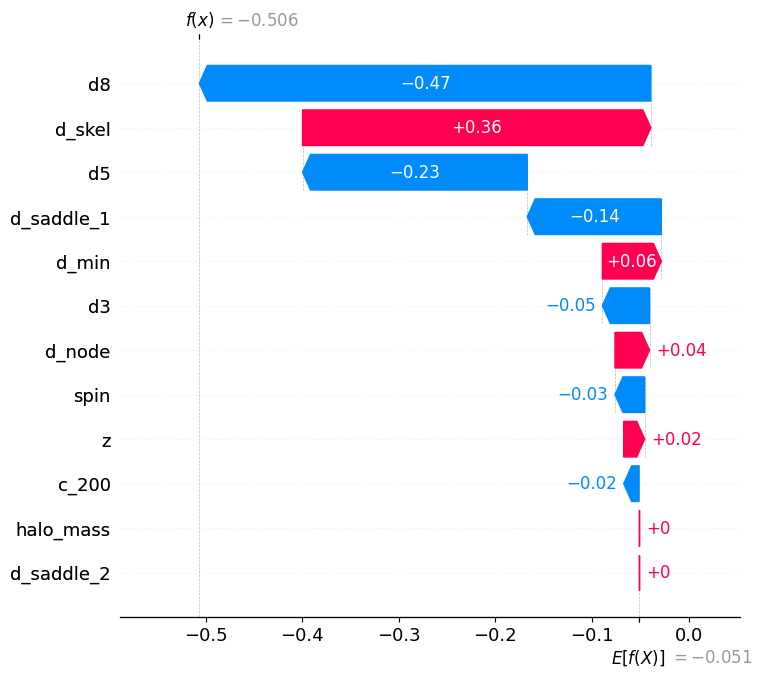

In [13]:
# Local explanation — waterfall for a single prediction
sample_id = 500
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[sample_id],
    feature_names=features,
    max_display=12
)